In [ ]:
# Actualizar rutas de datasets para nueva estructura organizada
dataset_path_con_sentimientos = '../data/processed/datasets_por_ciudad/sentimientos/simple/dataset_cdmx_sentimientos.csv'
dataset_path_original = '../data/processed/datasets_por_ciudad/base/dataset_cdmx.csv'

print("📁 Rutas actualizadas para nueva estructura:")
print(f"   📊 Dataset con sentimientos: {dataset_path_con_sentimientos}")
print(f"   📋 Dataset original: {dataset_path_original}")

# Análisis de Subjetividad de Opiniones Turísticas

Este notebook realiza un análisis de subjetividad sobre las opiniones turísticas recopiladas utilizando modelos preentrenados de HuggingFace para evaluar si el texto expresa opiniones subjetivas o información objetiva.

## Objetivos:
- Cargar dataset de una ciudad específica
- Aplicar modelo preentrenado de HuggingFace para análisis de subjetividad
- Clasificar texto en dos categorías: Subjetivo vs Objetivo
- Generar estadísticas descriptivas de la subjetividad
- Mostrar ejemplos representativos de cada categoría
- Crear visualizaciones del análisis

## Modelo utilizado:
- **GroNLP/mdebertav3-subjectivity-multilingual**: Modelo multilingüe especializado en análisis de subjetividad

In [ ]:
# Cargar dataset con análisis de sentimientos de CDMX
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Configurar rutas con nueva estructura organizada
dataset_path_con_sentimientos = '../data/processed/datasets_por_ciudad/sentimientos/simple/dataset_cdmx_sentimientos.csv'
dataset_path_original = '../data/processed/datasets_por_ciudad/base/dataset_cdmx.csv'

# Intentar cargar dataset con sentimientos primero
try:
    df = pd.read_csv(dataset_path_con_sentimientos)
    print(f"📊 Dataset con sentimientos cargado: {dataset_path_con_sentimientos}")
    tiene_sentimientos = True
except FileNotFoundError:
    print(f"⚠️ No se encontró el dataset con sentimientos: {dataset_path_con_sentimientos}")
    print("📋 Intentando cargar dataset original...")
    df = pd.read_csv(dataset_path_original)
    print(f"📊 Dataset original cargado: {dataset_path_original}")
    tiene_sentimientos = False

print(f"📊 Forma del dataset: {df.shape}")
print(f"🏙️  Ciudad: {df['Ciudad'].iloc[0] if 'Ciudad' in df.columns else 'No especificada'}")
print(f"🎯 Análisis de sentimientos disponible: {'✅ Sí' if tiene_sentimientos else '❌ No'}")

print(f"📝 Columnas disponibles:")
for i, col in enumerate(df.columns, 1):
    marca = "🆕" if col == 'SentimientoHF' else "  "
    print(f"   {i:2}. {col} {marca}")

# Mostrar las primeras filas
print(f"\n? MUESTRA DEL DATASET:")
if tiene_sentimientos:
    display(df[['TituloReview', 'Calificacion', 'SentimientoHF']].head())
else:
    display(df[['TituloReview', 'Calificacion']].head())

✅ Librerías importadas correctamente
✅ Módulo de análisis de subjetividad cargado (nueva estructura modular)
📁 Usando: subjetividad/analizador_huggingface_subjetividad.py


In [ ]:
# Cargar dataset con análisis de sentimientos incluido (generado en el notebook anterior)
# Primero intentamos cargar el dataset con sentimientos, si no existe, usamos el original

    "dataset_path_con_sentimientos = '../data/processed/datasets_por_ciudad/sentimientos/simple/dataset_cdmx_sentimientos.csv'
",
    "dataset_path_original = '../data/processed/datasets_por_ciudad/base/dataset_cdmx.csv'
",

try:
    # Intentar cargar el dataset con sentimientos
    df = pd.read_csv(dataset_path_con_sentimientos)
    print(f"📊 Dataset con sentimientos cargado: {dataset_path_con_sentimientos}")
    tiene_sentimientos = True
except FileNotFoundError:
    # Si no existe, cargar el dataset original
    print(f"⚠️  Dataset con sentimientos no encontrado, cargando dataset original...")
    df = pd.read_csv(dataset_path_original)
    print(f"📊 Dataset original cargado: {dataset_path_original}")
    tiene_sentimientos = False

print(f"📈 Dimensiones: {df.shape}")
print(f"🏙️  Ciudad: {df['Ciudad'].iloc[0] if 'Ciudad' in df.columns else 'No especificada'}")
print(f"🎯 Análisis de sentimientos disponible: {'✅ Sí' if tiene_sentimientos else '❌ No'}")

print(f"📝 Columnas disponibles:")
for i, col in enumerate(df.columns, 1):
    marca = "🆕" if col == 'SentimientoHF' else "  "
    print(f"   {i:2}. {col} {marca}")

# Mostrar las primeras filas
print(f"\n📋 MUESTRA DEL DATASET:")
if tiene_sentimientos:
    display(df[['TituloReview', 'Calificacion', 'SentimientoHF']].head())
else:
    display(df.head())

📊 Dataset con sentimientos cargado: ../data/processed/datasets_por_ciudad/dataset_cdmx_sentimientos.csv
📈 Dimensiones: (614, 12)
🏙️  Ciudad: Cdmx
🎯 Análisis de sentimientos disponible: ✅ Sí
📝 Columnas disponibles:
    1. Titulo   
    2. Review   
    3. TipoViaje   
    4. Calificacion   
    5. OrigenAutor   
    6. FechaOpinion   
    7. FechaEstadia   
    8. Ciudad   
    9. Atraccion   
   10. TituloReview   
   11. Sentimiento   
   12. SentimientoHF 🆕

📋 MUESTRA DEL DATASET:


,TituloReview,Calificacion,SentimientoHF
0,AVENIDA PRINCIPAL CIUDAD DE MÉXICO Avenida Ciu...,5,Positivo
1,"Hermoso 💚 Es hermoso su paisaje y recorrerlo, ...",5,Positivo
2,Sé consciente La foto de la entrada no coincid...,5,Negativo
3,Bicicleta dominical en la Reforma Está cerrado...,5,Negativo
4,Bella avenida México sin duda un excelente des...,4,Positivo


In [3]:
# Verificar e instalar transformers si es necesario
print("📦 Verificando librerías necesarias para HuggingFace...")

try:
    import transformers
    print("✅ Transformers ya está instalado")
    print(f"📍 Versión: {transformers.__version__}")
except ImportError:
    print("⏳ Instalando transformers...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "transformers[torch]"])
    print("✅ Transformers instalado exitosamente")

📦 Verificando librerías necesarias para HuggingFace...
✅ Transformers ya está instalado
📍 Versión: 4.56.1


In [4]:
# Inicializar el analizador de subjetividad con modelo específico
print("🤖 Inicializando analizador de subjetividad con HuggingFace...")
print("📋 Modelo seleccionado: GroNLP/mdebertav3-subjectivity-multilingual")
print("🌍 Características del modelo:")
print("   • Multilingüe (incluye español)")
print("   • Especializado en análisis de subjetividad")
print("   • Basado en DeBERTa v3")
print("   • Optimizado para textos de opiniones")

# Crear el analizador con el modelo específico
analizador = AnalizadorHuggingFaceSubjetividad(
    modelo_nombre="GroNLP/mdebertav3-subjectivity-multilingual"
)

# Cargar el modelo
exito = analizador.cargar_modelo()

if exito:
    print("\n🎯 INFORMACIÓN DEL MODELO CARGADO:")
    print("   • Tipo: Clasificación de texto (subjetividad)")
    print("   • Categorías: Subjetivo vs Objetivo")
    print("   • Entrada: Texto en múltiples idiomas")
    print("   • Salida: Probabilidades para cada categoría")
    print("   • Mapeo: LABEL_0 → Objetivo, LABEL_1 → Subjetivo")
    print("📁 Usando: AnalizadorHuggingFaceSubjetividad (nueva estructura modular)")
else:
    print("❌ No se pudo cargar el modelo de HuggingFace")
    print("💡 Verifica la conexión a internet y el nombre del modelo")

🤖 Inicializando analizador de subjetividad con HuggingFace...
📋 Modelo seleccionado: GroNLP/mdebertav3-subjectivity-multilingual
🌍 Características del modelo:
   • Multilingüe (incluye español)
   • Especializado en análisis de subjetividad
   • Basado en DeBERTa v3
   • Optimizado para textos de opiniones
🤖 Cargando modelo de subjetividad: GroNLP/mdebertav3-subjectivity-multilingual
⏳ Esto puede tomar unos momentos la primera vez...


Device set to use cuda:0


✅ Modelo cargado exitosamente
🌍 Modelo: GroNLP/mdebertav3-subjectivity-multilingual
📋 Especializado en: Análisis de subjetividad multilingüe

🎯 INFORMACIÓN DEL MODELO CARGADO:
   • Tipo: Clasificación de texto (subjetividad)
   • Categorías: Subjetivo vs Objetivo
   • Entrada: Texto en múltiples idiomas
   • Salida: Probabilidades para cada categoría
   • Mapeo: LABEL_0 → Objetivo, LABEL_1 → Subjetivo
📁 Usando: AnalizadorHuggingFaceSubjetividad (nueva estructura modular)


In [5]:
# Probar el modelo con algunos ejemplos manuales antes del análisis completo
print("🧪 PRUEBAS DEL MODELO CON EJEMPLOS MANUALES")
print("=" * 60)

# Ejemplos de prueba
ejemplos_prueba = [
    "Me encantó este lugar, es increíble y lo recomiendo mucho",
    "El museo abre de 9:00 AM a 6:00 PM todos los días",
    "Qué experiencia tan horrible, no vuelvo nunca más",
    "La entrada cuesta 150 pesos por persona",
    "Excelente atención al cliente, muy amables todos"
]

print("📝 Analizando ejemplos de prueba:")
print("-" * 60)

for i, ejemplo in enumerate(ejemplos_prueba, 1):
    resultado = analizador.analizar_subjetividad_texto(ejemplo)
    categoria = resultado['categoria']
    probabilidades = resultado['probabilidades']
    
    print(f"\n🔍 Ejemplo {i}:")
    print(f"   📝 Texto: \"{ejemplo}\"")
    print(f"   🏷️ Categoría: {categoria}")
    
    # Mostrar probabilidades si están disponibles
    if probabilidades:
        print(f"   📊 Probabilidades:")
        for prob in probabilidades:
            etiqueta = prob.get('label', 'Unknown')
            score = prob.get('score', 0) * 100
            print(f"      • {etiqueta}: {score:.1f}%")

print("\n✅ Pruebas del modelo completadas")
print("🚀 El modelo está funcionando correctamente")

🧪 PRUEBAS DEL MODELO CON EJEMPLOS MANUALES
📝 Analizando ejemplos de prueba:
------------------------------------------------------------

🔍 Ejemplo 1:
   📝 Texto: "Me encantó este lugar, es increíble y lo recomiendo mucho"
   🏷️ Categoría: Subjetivo
   📊 Probabilidades:
      • LABEL_0: 2.6%
      • LABEL_1: 97.4%

🔍 Ejemplo 1:
   📝 Texto: "Me encantó este lugar, es increíble y lo recomiendo mucho"
   🏷️ Categoría: Subjetivo
   📊 Probabilidades:
      • LABEL_0: 2.6%
      • LABEL_1: 97.4%

🔍 Ejemplo 2:
   📝 Texto: "El museo abre de 9:00 AM a 6:00 PM todos los días"
   🏷️ Categoría: Objetivo
   📊 Probabilidades:
      • LABEL_0: 98.9%
      • LABEL_1: 1.1%

🔍 Ejemplo 3:
   📝 Texto: "Qué experiencia tan horrible, no vuelvo nunca más"
   🏷️ Categoría: Subjetivo
   📊 Probabilidades:
      • LABEL_0: 1.7%
      • LABEL_1: 98.3%

🔍 Ejemplo 4:
   📝 Texto: "La entrada cuesta 150 pesos por persona"
   🏷️ Categoría: Objetivo
   📊 Probabilidades:
      • LABEL_0: 99.0%
      • LABEL_1: 1.0%

🔍 E

In [6]:
# Aplicar análisis de subjetividad al dataset completo
print("🚀 Iniciando análisis de subjetividad en dataset completo...")
print("⚠️  NOTA: Este proceso puede tomar 5-15 minutos dependiendo del hardware")
print(f"📊 Total de registros a procesar: {len(df)}")

# Procesar el dataset completo
df_con_subjetividad = analizador.procesar_dataset_completo(df, 'TituloReview')

print(f"\n✅ Análisis de subjetividad completado")
print(f"📊 Dataset ahora contiene {len(df_con_subjetividad.columns)} columnas")
print(f"🆕 Nueva columna agregada: 'SubjetividadHF'")

# Mostrar una muestra del resultado
print("\n" + "="*80)
print("MUESTRA DEL DATASET CON ANÁLISIS DE SUBJETIVIDAD")
print("="*80)
display(df_con_subjetividad[['TituloReview', 'Calificacion', 'SubjetividadHF']].head(10))

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


🚀 Iniciando análisis de subjetividad en dataset completo...
⚠️  NOTA: Este proceso puede tomar 5-15 minutos dependiendo del hardware
📊 Total de registros a procesar: 614
🚀 Iniciando análisis de subjetividad en dataset completo...
📊 Total de registros a procesar: 614
📦 Procesando lote 1/13 (registros 1-50)
📦 Procesando lote 2/13 (registros 51-100)
📦 Procesando lote 2/13 (registros 51-100)
📦 Procesando lote 3/13 (registros 101-150)
📦 Procesando lote 3/13 (registros 101-150)
📦 Procesando lote 4/13 (registros 151-200)
📦 Procesando lote 4/13 (registros 151-200)
📦 Procesando lote 5/13 (registros 201-250)
📦 Procesando lote 5/13 (registros 201-250)
📦 Procesando lote 6/13 (registros 251-300)
📦 Procesando lote 6/13 (registros 251-300)
📦 Procesando lote 7/13 (registros 301-350)
📦 Procesando lote 7/13 (registros 301-350)
📦 Procesando lote 8/13 (registros 351-400)
📦 Procesando lote 8/13 (registros 351-400)
📦 Procesando lote 9/13 (registros 401-450)
📦 Procesando lote 9/13 (registros 401-450)
📦 Proce

,TituloReview,Calificacion,SubjetividadHF
0,AVENIDA PRINCIPAL CIUDAD DE MÉXICO Avenida Ciu...,5,Objetivo
1,"Hermoso 💚 Es hermoso su paisaje y recorrerlo, ...",5,Subjetivo
2,Sé consciente La foto de la entrada no coincid...,5,Subjetivo
3,Bicicleta dominical en la Reforma Está cerrado...,5,Objetivo
4,Bella avenida México sin duda un excelente des...,4,Subjetivo
5,Caminé por parte de esta calle un domingo cuan...,3,Subjetivo
6,"""Caminata agradable"" El Paseo de la Reforma es...",4,Subjetivo
7,Caminata Es una calle que disfrutas desde que ...,5,Subjetivo
8,Me gustó venir Es una avenida llena de comerci...,5,Subjetivo
9,Muy disfrutable avenida Preciosa avenida paa r...,5,Subjetivo


In [7]:
# Generar y mostrar estadísticas descriptivas de la subjetividad
estadisticas = analizador.obtener_estadisticas_subjetividad(df_con_subjetividad)

# Mostrar estadísticas en consola
analizador.mostrar_estadisticas_consola(estadisticas)

# Mostrar tabla detallada por atracción
print("\n🎯 SUBJETIVIDAD POR ATRACCIÓN TURÍSTICA (Top 10):")
print("-" * 60)
if 'por_atraccion' in estadisticas and not estadisticas['por_atraccion'].empty:
    display(estadisticas['por_atraccion'].head(10))
else:
    print("No hay datos de atracciones disponibles")

📊 ESTADÍSTICAS DESCRIPTIVAS DE SUBJETIVIDAD
🔢 DISTRIBUCIÓN DE SUBJETIVIDAD:
----------------------------------------
 Subjetivo: 564 registros ( 91.9%)
  Objetivo:  50 registros (  8.1%)

📈 TOTAL DE REGISTROS: 614

📝 DESCRIPCIÓN DE CATEGORÍAS:
----------------------------------------
 Subjetivo: Texto que expresa opiniones, emociones, evaluaciones personales
  Objetivo: Texto que presenta hechos, información factual sin opiniones

🎯 SUBJETIVIDAD POR ATRACCIÓN TURÍSTICA (Top 10):
------------------------------------------------------------


SubjetividadHF,Objetivo,Subjetivo
Atraccion,,
Acuario Michin Ciudad De Mexico,1,73
Basilica De La Virgen Guadalupe,7,61
Jardines Flotantes De Xochimilco,5,64
Mercado De Artesanias La Ciudadela,6,57
Museo Del Templo Mayor,6,47
Museo Nacional De Antropologia,2,41
Palacio De Bellas Artes,5,60
Paseo De La Reforma,5,55
Polanco,8,49


📈 GENERANDO VISUALIZACIONES BÁSICAS
📈 GENERANDO VISUALIZACIONES DE SUBJETIVIDAD
✅ Visualizaciones generadas exitosamente
✅ Visualizaciones generadas exitosamente


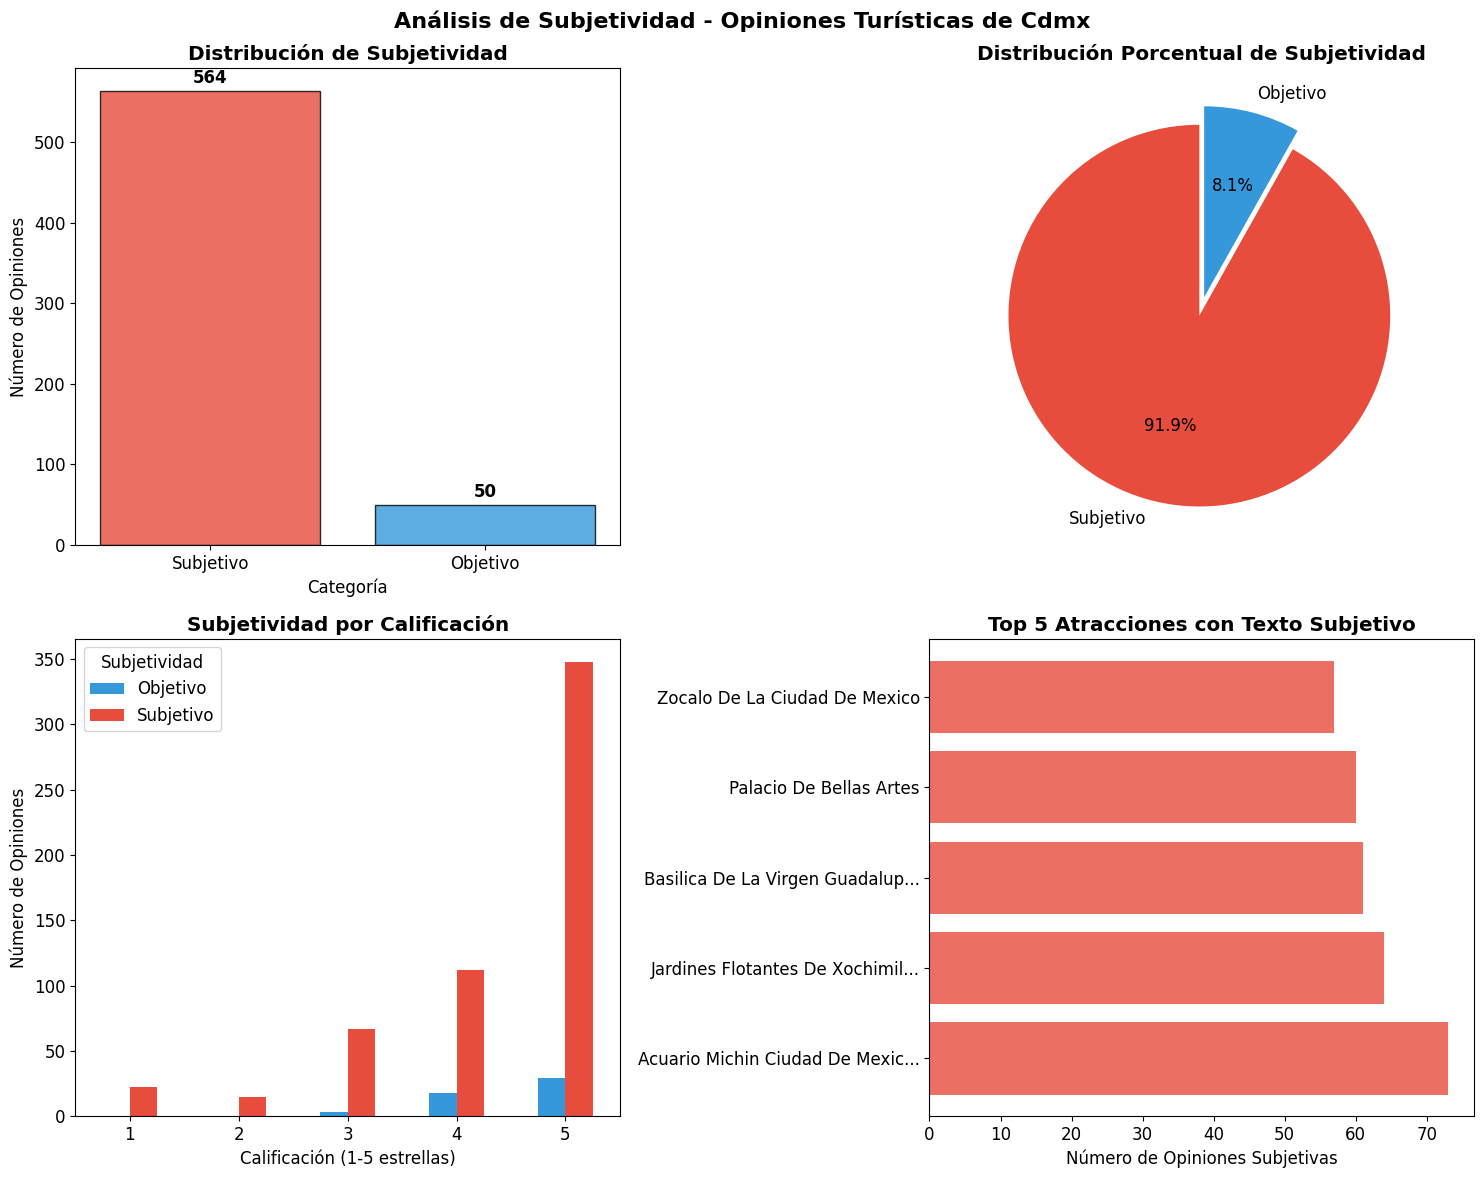

✅ Visualizaciones básicas generadas exitosamente
📁 Usando: VisualizadorSubjetividad.crear_visualizaciones_basicas()


In [8]:
# Crear visualizaciones básicas de la subjetividad
print("📈 GENERANDO VISUALIZACIONES BÁSICAS")
print("=" * 50)

visualizador = VisualizadorSubjetividad()
ciudad = df_con_subjetividad['Ciudad'].iloc[0] if 'Ciudad' in df_con_subjetividad.columns else "Ciudad de México"

fig_basicas = visualizador.crear_visualizaciones_basicas(df_con_subjetividad, ciudad)
plt.show()

print("✅ Visualizaciones básicas generadas exitosamente")
print("📁 Usando: VisualizadorSubjetividad.crear_visualizaciones_basicas()")

📊 GENERANDO VISUALIZACIONES DETALLADAS
✅ Visualizaciones detalladas generadas exitosamente
✅ Visualizaciones detalladas generadas exitosamente


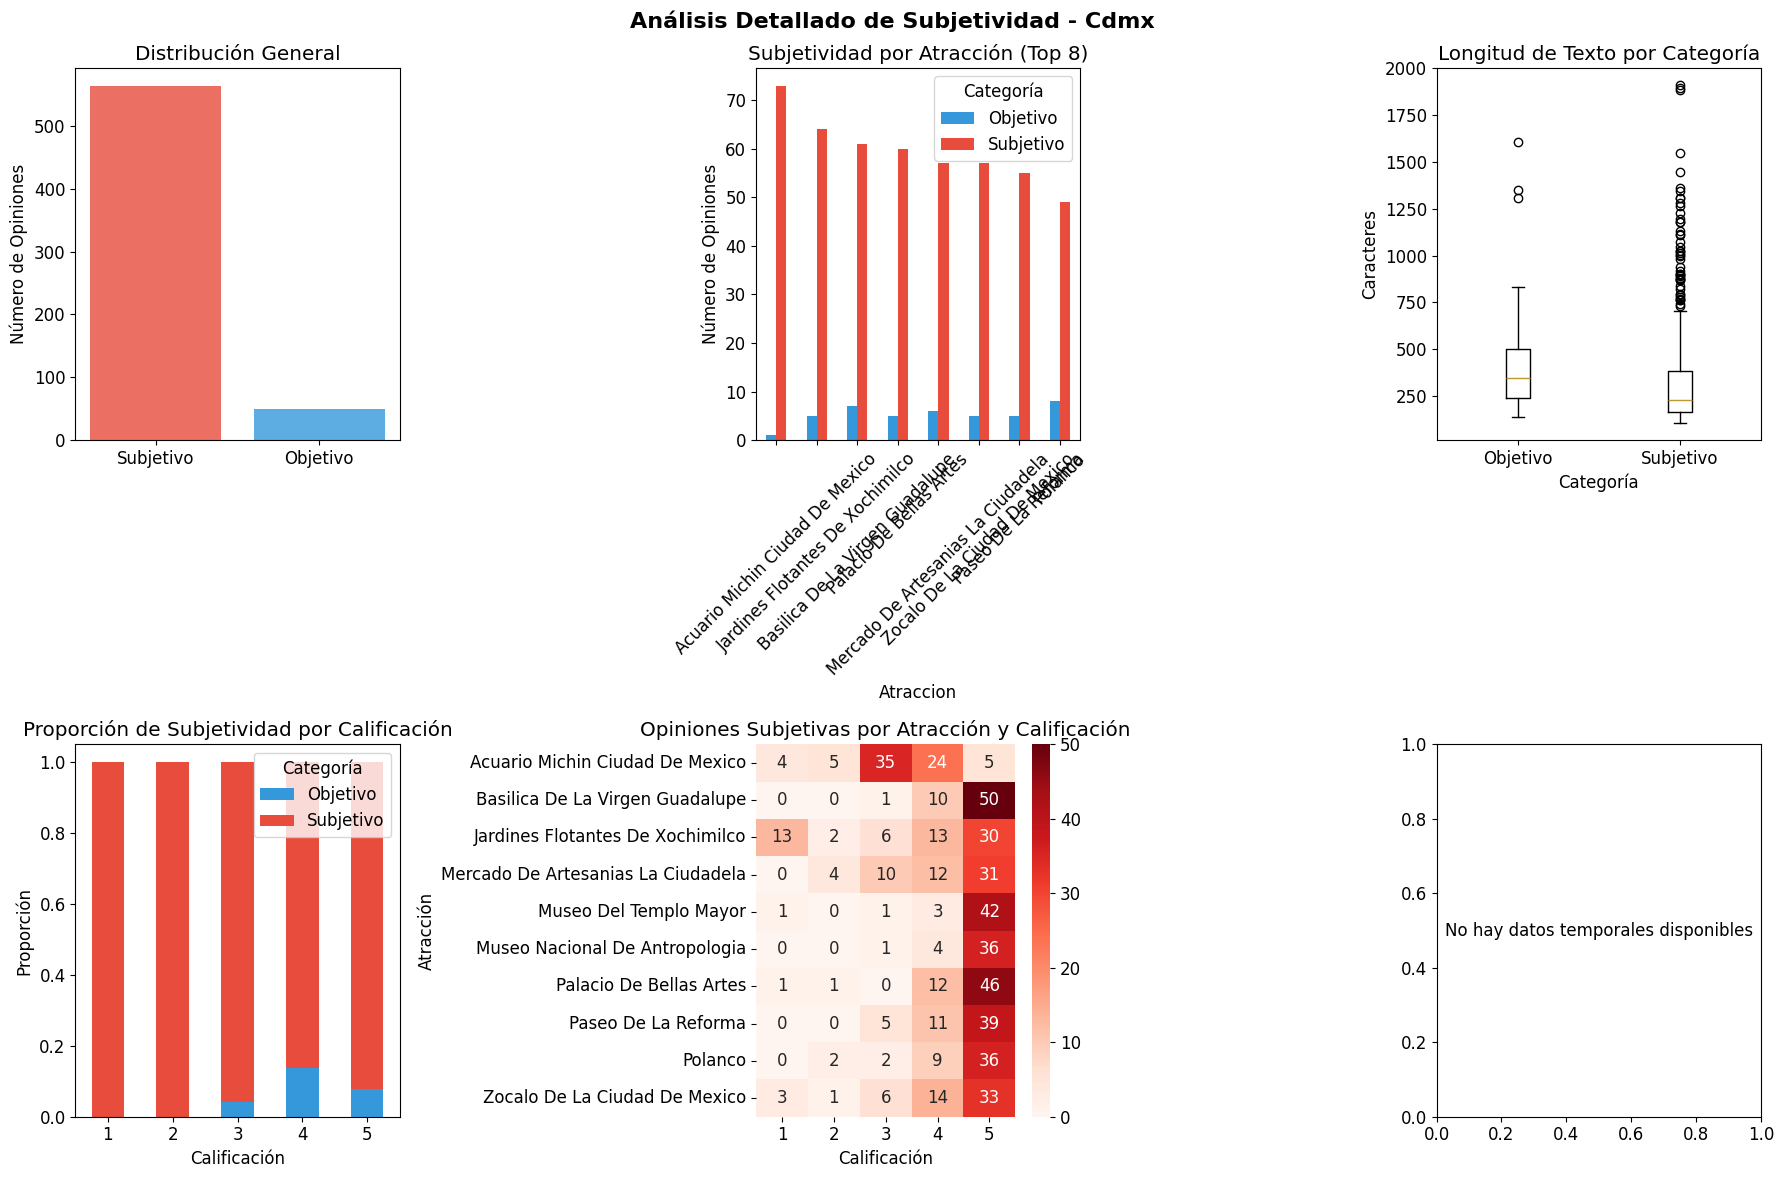

✅ Visualizaciones detalladas generadas exitosamente
📁 Usando: VisualizadorSubjetividad.crear_visualizacion_detallada()


In [9]:
# Crear visualizaciones detalladas de la subjetividad
print("📊 GENERANDO VISUALIZACIONES DETALLADAS")
print("=" * 50)

fig_detalladas = visualizador.crear_visualizacion_detallada(df_con_subjetividad, ciudad)
plt.show()

print("✅ Visualizaciones detalladas generadas exitosamente")
print("📁 Usando: VisualizadorSubjetividad.crear_visualizacion_detallada()")

# Análisis Combinado: Subjetividad vs Sentimientos

En esta sección analizaremos la relación entre la subjetividad del texto y los sentimientos expresados. Esto nos permitirá entender:

- **¿El texto subjetivo tiende a ser más positivo o negativo?**
- **¿El texto objetivo mantiene neutralidad en los sentimientos?**
- **¿Cómo se distribuyen los sentimientos dentro de cada categoría de subjetividad?**
- **¿Existe correlación entre ser subjetivo y expresar sentimientos extremos?**

Este análisis combinado nos dará una visión más completa del comportamiento emocional y la objetividad en las opiniones turísticas.

In [10]:
# Análisis estadístico de la relación entre subjetividad y sentimientos
print("🔍 ANÁLISIS COMBINADO: SUBJETIVIDAD vs SENTIMIENTOS")
print("=" * 70)

# Verificar si tenemos datos de sentimientos
if tiene_sentimientos and 'SentimientoHF' in df_con_subjetividad.columns:
    # Realizar análisis combinado
    estadisticas_combinadas = analizador.analizar_subjetividad_por_sentimientos(df_con_subjetividad)
    
    # Mostrar estadísticas en consola
    analizador.mostrar_estadisticas_subjetividad_sentimientos(estadisticas_combinadas)
    
    print(f"\n📊 DATOS DISPONIBLES PARA ANÁLISIS COMBINADO:")
    print(f"   ✅ Subjetividad: Disponible")
    print(f"   ✅ Sentimientos: Disponible") 
    print(f"   ✅ Análisis combinado: Completado")
    
else:
    print(f"⚠️  ANÁLISIS COMBINADO NO DISPONIBLE")
    print(f"   ❌ No se encontraron datos de sentimientos (SentimientoHF)")
    print(f"   💡 Para obtener este análisis:")
    print(f"      1. Ejecuta primero el notebook '02-analisis-de-sentimientos.ipynb'")
    print(f"      2. Asegúrate de que se genere el archivo 'dataset_cdmx_sentimientos.csv'")
    print(f"      3. Vuelve a ejecutar este notebook")
    
    estadisticas_combinadas = None

🔍 ANÁLISIS COMBINADO: SUBJETIVIDAD vs SENTIMIENTOS

📊 ANÁLISIS DE SUBJETIVIDAD vs SENTIMIENTOS
📈 Total de registros analizados: 614
📝 Texto subjetivo: 564 (91.9%)
📋 Texto objetivo: 50 (8.1%)

📋 TABLA CRUZADA COMPLETA:
----------------------------------------
SentimientoHF   Negativo  Neutro  Positivo  All
SubjetividadHF                                 
Objetivo               4       6        40   50
Subjetivo             62      43       459  564
All                   66      49       499  614

📊 DISTRIBUCIÓN PORCENTUAL POR SUBJETIVIDAD:
--------------------------------------------------
SentimientoHF   Negativo  Neutro  Positivo
SubjetividadHF                            
Objetivo             8.0    12.0      80.0
Subjetivo           11.0     7.6      81.4

🔍 SENTIMIENTOS EN TEXTO SUBJETIVO:
----------------------------------------
   • Positivo: 459 (81.4%)
   • Negativo: 62 (11.0%)
   • Neutro: 43 (7.6%)

🔍 SENTIMIENTOS EN TEXTO OBJETIVO:
----------------------------------------
   •

📈 GENERANDO VISUALIZACIONES DEL ANÁLISIS COMBINADO
📊 CREANDO VISUALIZACIONES DE SUBJETIVIDAD vs SENTIMIENTOS
✅ Visualizaciones de subjetividad vs sentimientos generadas exitosamente


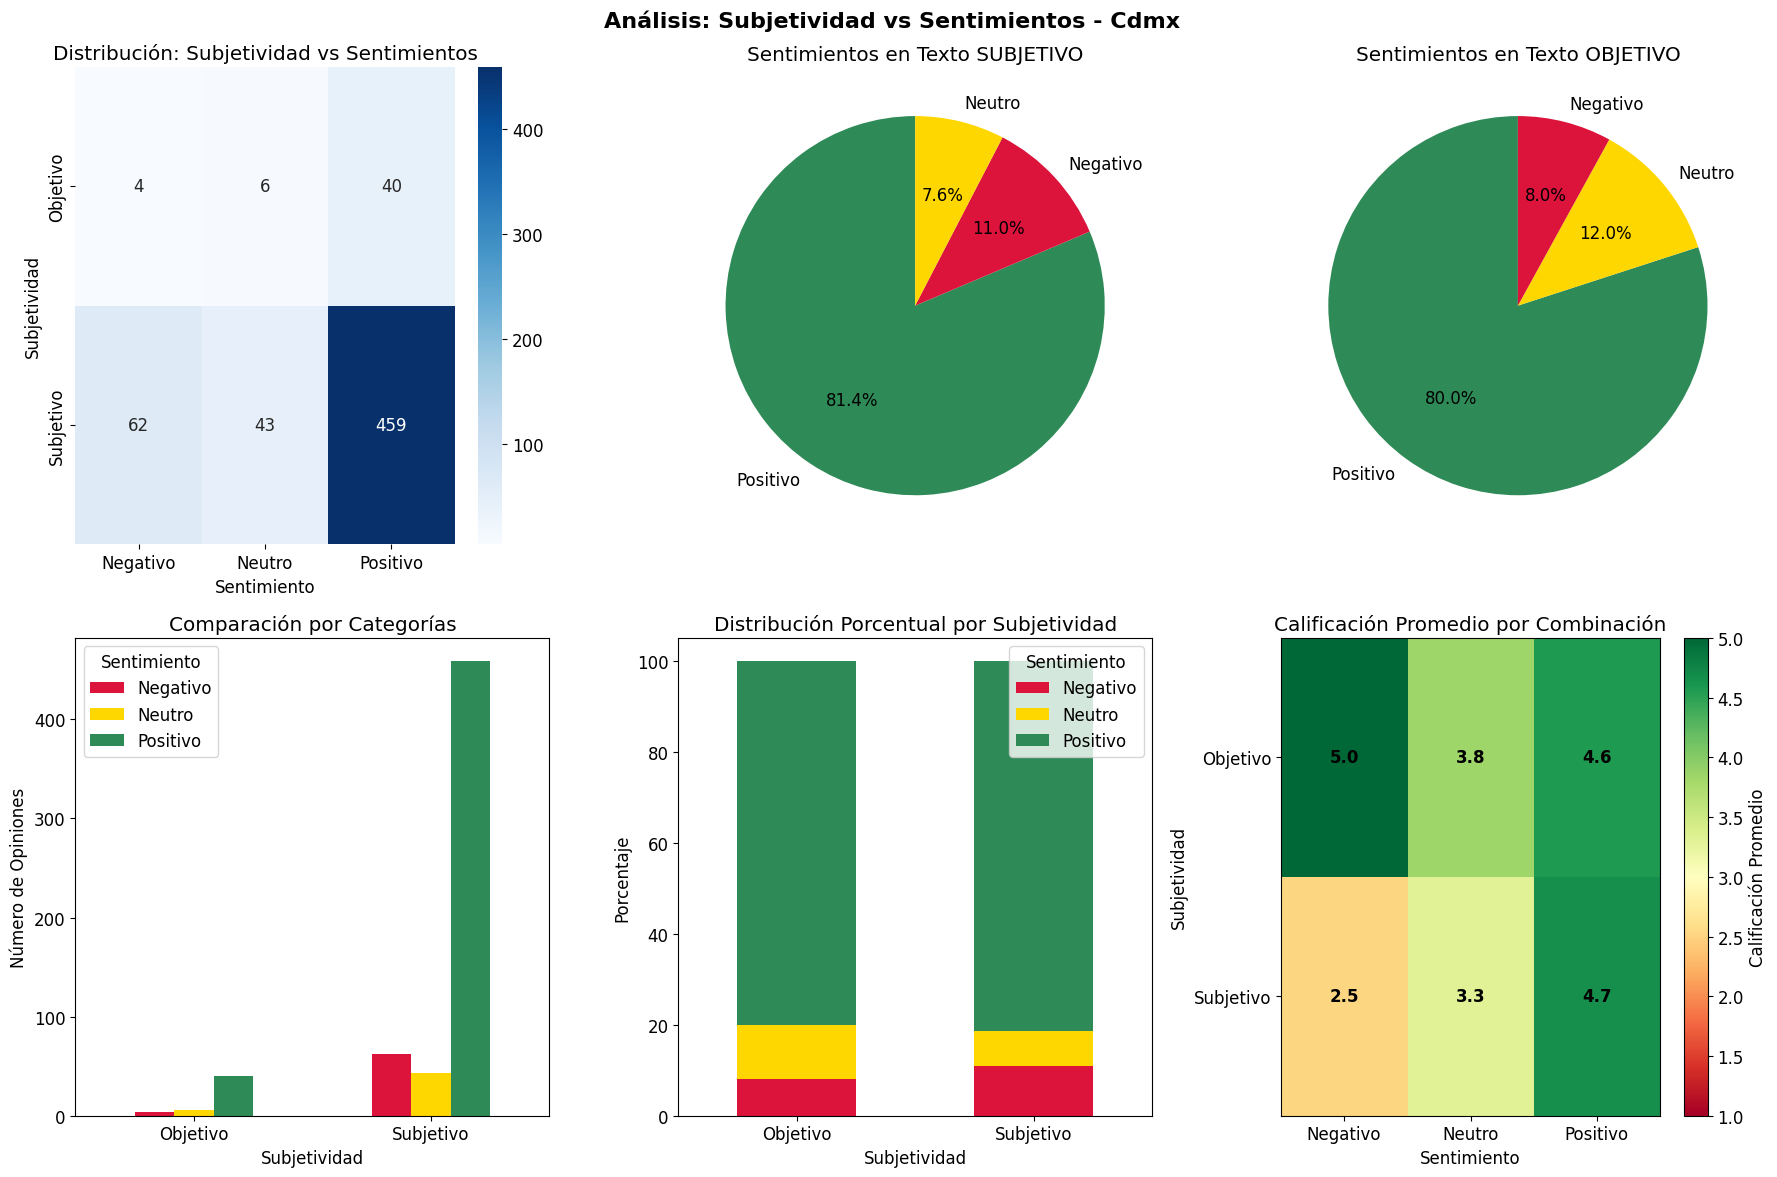

✅ Visualizaciones del análisis combinado generadas exitosamente
📁 Usando: VisualizadorSubjetividad.crear_visualizacion_subjetividad_vs_sentimientos()


In [11]:
# Crear visualizaciones del análisis combinado
print("📈 GENERANDO VISUALIZACIONES DEL ANÁLISIS COMBINADO")
print("=" * 60)

if tiene_sentimientos and 'SentimientoHF' in df_con_subjetividad.columns:
    # Crear visualizaciones específicas para subjetividad vs sentimientos
    fig_combinado = visualizador.crear_visualizacion_subjetividad_vs_sentimientos(df_con_subjetividad, ciudad)
    
    if fig_combinado:
        plt.show()
        print("✅ Visualizaciones del análisis combinado generadas exitosamente")
        print("📁 Usando: VisualizadorSubjetividad.crear_visualizacion_subjetividad_vs_sentimientos()")
    else:
        print("❌ Error al generar las visualizaciones combinadas")
else:
    print("⚠️  No se pueden crear visualizaciones combinadas sin datos de sentimientos")
    print("💡 Ejecuta primero el notebook de análisis de sentimientos")

In [12]:
# Análisis detallado por categorías de sentimiento
print("🔍 ANÁLISIS DETALLADO POR SENTIMIENTOS")
print("=" * 60)

if tiene_sentimientos and 'SentimientoHF' in df_con_subjetividad.columns:
    
    # Analizar cada sentimiento por separado
    sentimientos = df_con_subjetividad['SentimientoHF'].unique()
    
    for sentimiento in sentimientos:
        print(f"\n🎯 ANÁLISIS DE OPINIONES {sentimiento.upper()}")
        print("-" * 50)
        
        df_sentimiento = df_con_subjetividad[df_con_subjetividad['SentimientoHF'] == sentimiento]
        total_sentimiento = len(df_sentimiento)
        
        print(f"📊 Total de opiniones {sentimiento.lower()}: {total_sentimiento}")
        
        # Distribución de subjetividad en este sentimiento
        subjetividad_en_sentimiento = df_sentimiento['SubjetividadHF'].value_counts()
        print(f"📋 Distribución de subjetividad en opiniones {sentimiento.lower()}:")
        
        for subj_tipo, cantidad in subjetividad_en_sentimiento.items():
            porcentaje = (cantidad / total_sentimiento) * 100
            print(f"   • {subj_tipo}: {cantidad} ({porcentaje:.1f}%)")
        
        # Mostrar algunos ejemplos
        print(f"\n📝 Ejemplos de opiniones {sentimiento.lower()}:")
        ejemplos = df_sentimiento.sample(min(3, len(df_sentimiento)))
        
        for idx, (_, row) in enumerate(ejemplos.iterrows(), 1):
            texto = str(row['TituloReview'])
            subjetividad = row['SubjetividadHF']
            calificacion = row['Calificacion'] if 'Calificacion' in row else 'N/A'
            
            print(f"\n   {idx}. 📝 \"{texto[:100]}{'...' if len(texto) > 100 else ''}\"")
            print(f"      🏷️  Subjetividad: {subjetividad}")
            print(f"      ⭐ Calificación: {calificacion}")
    
    # Resumen final del análisis combinado
    print(f"\n" + "🏆" * 25 + " RESUMEN FINAL " + "🏆" * 25)
    print("=" * 70)
    print("📋 CONCLUSIONES DEL ANÁLISIS COMBINADO:")
    print("-" * 40)
    
    # Calcular insights principales
    total_opiniones = len(df_con_subjetividad)
    
    for sentimiento in sentimientos:
        df_sent = df_con_subjetividad[df_con_subjetividad['SentimientoHF'] == sentimiento]
        subjetivos_en_sent = len(df_sent[df_sent['SubjetividadHF'] == 'Subjetivo'])
        porcentaje_subj = (subjetivos_en_sent / len(df_sent)) * 100 if len(df_sent) > 0 else 0
        
        print(f"• En opiniones {sentimiento.lower()}: {porcentaje_subj:.1f}% del texto es subjetivo")
    
    # Calcular la distribución general
    print(f"\n📊 DISTRIBUCIÓN GENERAL:")
    print(f"   • Total de opiniones analizadas: {total_opiniones}")
    print(f"   • Sentimientos únicos encontrados: {len(sentimientos)}")
    print(f"   • Combinaciones subjetividad-sentimiento: {len(df_con_subjetividad.groupby(['SubjetividadHF', 'SentimientoHF']))}")

else:
    print("⚠️  Análisis detallado no disponible sin datos de sentimientos")
    print("💡 Ejecuta el notebook de análisis de sentimientos primero")

🔍 ANÁLISIS DETALLADO POR SENTIMIENTOS

🎯 ANÁLISIS DE OPINIONES POSITIVO
--------------------------------------------------
📊 Total de opiniones positivo: 499
📋 Distribución de subjetividad en opiniones positivo:
   • Subjetivo: 459 (92.0%)
   • Objetivo: 40 (8.0%)

📝 Ejemplos de opiniones positivo:

   1. 📝 "Basílica interesante Tal vez no la más grande pero una de las basílicas más importantes. Incluso vis..."
      🏷️  Subjetividad: Subjetivo
      ⭐ Calificación: 5

   2. 📝 "Hermoso paseo por el lago Xochimilco con música de mariachi, maíz frito y bebidas a bordo.Lo que rec..."
      🏷️  Subjetividad: Subjetivo
      ⭐ Calificación: 5

   3. 📝 "En busca de embarcadero Nativitas Se debe tener claro a que embarcadero se desea llegar pues de eso ..."
      🏷️  Subjetividad: Subjetivo
      ⭐ Calificación: 5

🎯 ANÁLISIS DE OPINIONES NEGATIVO
--------------------------------------------------
📊 Total de opiniones negativo: 66
📋 Distribución de subjetividad en opiniones negativo:
   • Sub

In [13]:
# Mostrar ejemplos representativos de texto SUBJETIVO
print("🔍 EJEMPLOS DE TEXTO SUBJETIVO")
print("=" * 70)
print("📝 Los siguientes ejemplos muestran opiniones, emociones y evaluaciones personales:")
print()

analizador.mostrar_ejemplos_categoria(
    df_con_subjetividad, 
    categoria='Subjetivo', 
    n_ejemplos=5,
    mostrar_texto_completo=True
)

🔍 EJEMPLOS DE TEXTO SUBJETIVO
📝 Los siguientes ejemplos muestran opiniones, emociones y evaluaciones personales:


🎯 EJEMPLOS DE TEXTO SUBJETIVO
----------------------------------------------------------------------

📌 Ejemplo 1:
   🏛️ Atracción: Palacio De Bellas Artes
   ⭐ Calificación: 5 estrellas
   📝 Texto completo:
      "Hermoso Se ve hermoso de noche, y ese parque es una fiesta en cada esquina, sonideros y al gente bailando, recomiendo no saltarse esa actividad"
   🏷️ Categoría: Subjetivo

📌 Ejemplo 2:
   🏛️ Atracción: Zocalo De La Ciudad De Mexico
   ⭐ Calificación: 3 estrellas
   📝 Texto completo:
      "Zócalo es centro de mucho para disfrutar. Si sólo miras el Zócalo, la historia está ahí, pero también los vendedores y las molestias. Si cuentas todo el barrio, con el Templo, la Catedral, los museos, algunas tiendas bonitas y la historia que está en todas partes, la calificación aparece al instante.Es imprescindible para los sentidos."
   🏷️ Categoría: Subjetivo

📌 Ejemplo 3

In [14]:
# Mostrar ejemplos representativos de texto OBJETIVO
print("🔍 EJEMPLOS DE TEXTO OBJETIVO")
print("=" * 70)
print("📝 Los siguientes ejemplos muestran información factual sin opiniones personales:")
print()

analizador.mostrar_ejemplos_categoria(
    df_con_subjetividad, 
    categoria='Objetivo', 
    n_ejemplos=5,
    mostrar_texto_completo=True
)

🔍 EJEMPLOS DE TEXTO OBJETIVO
📝 Los siguientes ejemplos muestran información factual sin opiniones personales:


🎯 EJEMPLOS DE TEXTO OBJETIVO
----------------------------------------------------------------------

📌 Ejemplo 1:
   🏛️ Atracción: Palacio De Bellas Artes
   ⭐ Calificación: 5 estrellas
   📝 Texto completo:
      "Palacio de Bellas Artes El Palacio de Bellas Artes es un recinto arquitectónico de estilo Art Deco realizado por Adamo Boari en la primera mitad del  Siglo XX, en su interior hallarás una serie de Murales de los mejores artistas tales como David Alfaro Sequeiros, Jose Clemente Orozco y Diego Rivera (entre otros)"
   🏷️ Categoría: Objetivo

📌 Ejemplo 2:
   🏛️ Atracción: Jardines Flotantes De Xochimilco
   ⭐ Calificación: 3 estrellas
   📝 Texto completo:
      "Bumper Boats Vinimos a Xochimilco como parte de una gira. Hablando de una trampa turística. Si bien los barcos son coloridos, se puede disfrutar del mariachi, comida y bebidas, no hay nada que ver. Los muelles 

In [15]:
# Mostrar TODOS los ejemplos de ambas categorías (muestra más amplia)
print("📋 MUESTRA AMPLIA DE TODAS LAS CATEGORÍAS")
print("=" * 70)

analizador.mostrar_todos_los_ejemplos(df_con_subjetividad, n_ejemplos=10)

print("\n" + "🔄" * 25 + " ANÁLISIS ADICIONAL " + "🔄" * 25)

📋 MUESTRA AMPLIA DE TODAS LAS CATEGORÍAS
🔍 EJEMPLOS REPRESENTATIVOS POR CATEGORÍA DE SUBJETIVIDAD

🎯 EJEMPLOS DE TEXTO SUBJETIVO
----------------------------------------------------------------------

📌 Ejemplo 1:
   🏛️ Atracción: Paseo De La Reforma
   ⭐ Calificación: 5 estrellas
   📝 Texto completo:
      "Alejandro Avalos un genial anfitrión siempre atento Carne de calidad y los detalles estuvieron de maravilla. Atención de primera . Desde la llegada la anfitriona nos atendió de lujo buscándonos una linda mesa . Tequila 100 % Vinos mexicano de Valle increíbles"
   🏷️ Categoría: Subjetivo

📌 Ejemplo 2:
   🏛️ Atracción: Museo Del Templo Mayor
   ⭐ Calificación: 5 estrellas
   📝 Texto completo:
      "Un viaje al centro del pueblo azteca. Maravillosa experiencia para entender la cultura y sociedad del Pueblo Azteca. Ubicado en el centro de la Ciudad de México, junto a la Catedral Nacional, este museo al aire libre / interior te lleva a la historia. El museo comienza en el exterior most

In [16]:
# Análisis adicional: Relación entre subjetividad y calificaciones
print("📊 ANÁLISIS DE RELACIÓN: SUBJETIVIDAD vs CALIFICACIONES")
print("=" * 70)

if 'Calificacion' in df_con_subjetividad.columns:
    # Tabla cruzada
    tabla_cruzada = pd.crosstab(
        df_con_subjetividad['SubjetividadHF'], 
        df_con_subjetividad['Calificacion'], 
        margins=True
    )
    
    print("📋 TABLA CRUZADA: Subjetividad vs Calificación")
    print("-" * 50)
    display(tabla_cruzada)
    
    # Análisis porcentual
    tabla_porcentual = pd.crosstab(
        df_con_subjetividad['SubjetividadHF'], 
        df_con_subjetividad['Calificacion'], 
        normalize='columns'
    ) * 100
    
    print("\n📊 DISTRIBUCIÓN PORCENTUAL POR CALIFICACIÓN:")
    print("-" * 50)
    display(tabla_porcentual.round(1))
    
    # Insights
    print("\n💡 INSIGHTS PRINCIPALES:")
    print("-" * 30)
    total_subjetivo = (df_con_subjetividad['SubjetividadHF'] == 'Subjetivo').sum()
    total_objetivo = (df_con_subjetividad['SubjetividadHF'] == 'Objetivo').sum()
    porcentaje_subjetivo = (total_subjetivo / len(df_con_subjetividad)) * 100
    
    print(f"• {porcentaje_subjetivo:.1f}% del contenido es subjetivo")
    print(f"• {100-porcentaje_subjetivo:.1f}% del contenido es objetivo")
    
    # Calificación promedio por tipo
    if total_subjetivo > 0:
        cal_prom_subjetivo = df_con_subjetividad[df_con_subjetividad['SubjetividadHF'] == 'Subjetivo']['Calificacion'].mean()
        print(f"• Calificación promedio en texto subjetivo: {cal_prom_subjetivo:.1f} estrellas")
    
    if total_objetivo > 0:
        cal_prom_objetivo = df_con_subjetividad[df_con_subjetividad['SubjetividadHF'] == 'Objetivo']['Calificacion'].mean()
        print(f"• Calificación promedio en texto objetivo: {cal_prom_objetivo:.1f} estrellas")

else:
    print("❌ No hay datos de calificaciones disponibles para el análisis")

📊 ANÁLISIS DE RELACIÓN: SUBJETIVIDAD vs CALIFICACIONES
📋 TABLA CRUZADA: Subjetividad vs Calificación
--------------------------------------------------


Calificacion,1,2,3,4,5,All
SubjetividadHF,,,,,,
Objetivo,0,0,3,18,29,50
Subjetivo,22,15,67,112,348,564
All,22,15,70,130,377,614



📊 DISTRIBUCIÓN PORCENTUAL POR CALIFICACIÓN:
--------------------------------------------------


Calificacion,1,2,3,4,5
SubjetividadHF,,,,,
Objetivo,0.0,0.0,4.3,13.8,7.7
Subjetivo,100.0,100.0,95.7,86.2,92.3



💡 INSIGHTS PRINCIPALES:
------------------------------
• 91.9% del contenido es subjetivo
• 8.1% del contenido es objetivo
• Calificación promedio en texto subjetivo: 4.3 estrellas
• Calificación promedio en texto objetivo: 4.5 estrellas


In [17]:
# Generar resumen final completo incluyendo análisis combinado
analizador.generar_resumen_final(df_con_subjetividad)

print("\n" + "🏆" * 30 + " COMPLETADO " + "🏆" * 30)
print("=" * 80)
print("📊 RESUMEN FINAL DEL ANÁLISIS DE SUBJETIVIDAD")
print("=" * 80)
print(f"✅ Análisis completado para {len(df_con_subjetividad)} opiniones turísticas")
print(f"🏙️ Ciudad analizada: {ciudad}")
print(f"🎯 Atracciones únicas: {df_con_subjetividad['Atraccion'].nunique() if 'Atraccion' in df_con_subjetividad.columns else 'N/A'}")
print(f"🤖 Modelo utilizado: GroNLP/mdebertav3-subjectivity-multilingual")
print(f"📈 Nuevas columnas generadas: SubjetividadHF")

# Mostrar distribución final de subjetividad
distribucion_final = df_con_subjetividad['SubjetividadHF'].value_counts()
print(f"\n📋 DISTRIBUCIÓN FINAL DE SUBJETIVIDAD:")
for categoria, cantidad in distribucion_final.items():
    porcentaje = (cantidad / len(df_con_subjetividad)) * 100
    print(f"   • {categoria}: {cantidad} opiniones ({porcentaje:.1f}%)")

# Información sobre análisis combinado
if tiene_sentimientos and 'SentimientoHF' in df_con_subjetividad.columns:
    print(f"\n🔄 ANÁLISIS COMBINADO REALIZADO:")
    print(f"   ✅ Subjetividad vs Sentimientos: Completado")
    print(f"   📊 Combinaciones analizadas: {len(df_con_subjetividad.groupby(['SubjetividadHF', 'SentimientoHF']))}")
    
    # Mostrar distribución de sentimientos
    distribucion_sentimientos = df_con_subjetividad['SentimientoHF'].value_counts()
    print(f"\n📋 DISTRIBUCIÓN DE SENTIMIENTOS:")
    for sentimiento, cantidad in distribucion_sentimientos.items():
        porcentaje = (cantidad / len(df_con_subjetividad)) * 100
        print(f"   • {sentimiento}: {cantidad} opiniones ({porcentaje:.1f}%)")
    
    print(f"\n🔗 CORRELACIONES PRINCIPALES:")
    if estadisticas_combinadas:
        # Mostrar insights clave del análisis combinado
        subj_positivos = estadisticas_combinadas['subjetivos_sentimientos'].get('Positivo', 0)
        subj_total = estadisticas_combinadas['subjetivos_total']
        if subj_total > 0:
            porcentaje_subj_pos = (subj_positivos / subj_total) * 100
            print(f"   • {porcentaje_subj_pos:.1f}% del texto subjetivo es positivo")
        
        obj_positivos = estadisticas_combinadas['objetivos_sentimientos'].get('Positivo', 0)
        obj_total = estadisticas_combinadas['objetivos_total'] 
        if obj_total > 0:
            porcentaje_obj_pos = (obj_positivos / obj_total) * 100
            print(f"   • {porcentaje_obj_pos:.1f}% del texto objetivo es positivo")
else:
    print(f"\n⚠️  ANÁLISIS COMBINADO NO REALIZADO:")
    print(f"   ❌ No se encontraron datos de sentimientos")
    print(f"   💡 Para análisis completo, ejecuta primero el notebook de sentimientos")

print(f"\n🏗️ ESTRUCTURA MODULAR UTILIZADA:")
print(f"   📁 subjetividad/base_subjetividad.py")
print(f"   📁 subjetividad/analizador_huggingface_subjetividad.py")
print(f"   📁 subjetividad/visualizaciones_subjetividad.py")
print(f"   📁 subjetividad/utils_subjetividad.py")
if tiene_sentimientos:
    print(f"   📁 sentimientos/utils_sentimientos.py (para carga de datos)")

print(f"\n💾 ARCHIVOS GENERADOS:")
if tiene_sentimientos:
    print(f"   📄 dataset_cdmx_sentimientos.csv (con SentimientoHF)")
print(f"   📄 df_con_subjetividad (en memoria, con SubjetividadHF)")
print(f"\n💾 Para exportar resultados finales, usa:")
print(f"   df_con_subjetividad.to_csv('resultados_subjetividad_completo.csv', index=False)")
print("=" * 80)


🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆 RESUMEN FINAL 🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
✅ Análisis de subjetividad completado exitosamente
🏙️ Ciudad analizada: Cdmx
📊 Total de opiniones analizadas: 614
🎯 Atracciones únicas: 10
🤖 Modelo utilizado: GroNLP/mdebertav3-subjectivity-multilingual
📊 ESTADÍSTICAS DESCRIPTIVAS DE SUBJETIVIDAD
🔢 DISTRIBUCIÓN DE SUBJETIVIDAD:
----------------------------------------
 Subjetivo: 564 registros ( 91.9%)
  Objetivo:  50 registros (  8.1%)

📈 TOTAL DE REGISTROS: 614

📝 DESCRIPCIÓN DE CATEGORÍAS:
----------------------------------------
 Subjetivo: Texto que expresa opiniones, emociones, evaluaciones personales
  Objetivo: Texto que presenta hechos, información factual sin opiniones

🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆 COMPLETADO 🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
📊 RESUMEN FINAL DEL ANÁLISIS DE SUBJETIVIDAD
✅ Análisis completado para 614 opiniones turísticas
🏙️ Ciudad analizada: Cdmx
🎯 Atracciones únicas: 10
🤖 Modelo utilizado: GroNLP/mdebertav3-subjectivity-multilingual
📈 Nuevas c